# Forecastability Fingerprint Showcase

This walkthrough is the canonical v0.3.1 fingerprint notebook. It uses the prepared
synthetic archetypes from `forecastability.utils.synthetic` and keeps the full story
strictly deterministic: geometry, linear baseline, fingerprint fields, routing, and
the A3 agent-layer explanation all come from reusable package surfaces.

Sections:
- A. What the fingerprint solves
- B. Why four fields instead of disconnected diagnostics
- C. Canonical benchmark series generation
- D. `information_mass` walkthrough
- E. `information_horizon` walkthrough
- F. `information_structure` walkthrough with peak-spacing visuals
- G. `nonlinear_share` walkthrough against the Gaussian-information baseline
- H. Routing walkthrough with caution flags and confidence labels
- I. Agent-layer summary in plain language
- J. Verification and caveats


## Setup

The notebook does not reimplement any science locally. It calls:

- `generate_fingerprint_archetypes()` for the prepared synthetic panel,
- `run_forecastability_fingerprint()` for geometry + fingerprint + routing,
- `compute_linear_information_curve()` for the Gaussian baseline used by `nonlinear_share`,
- `build_fingerprint_showcase_record()` plus the notebook-facing reporting helpers for the
  strict A1/A2/A3 agent summary and reusable figures.


In [1]:
%matplotlib inline

In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from forecastability import (
    build_fingerprint_showcase_record,
    build_plain_language_math_summary,
    fingerprint_profile_frame,
    routing_table_frame,
    save_metric_overview,
    save_showcase_profile_grid,
    showcase_summary_frame,
    verify_showcase_records,
    write_frame_csv,
)
from forecastability import compute_linear_information_curve
from forecastability import run_forecastability_fingerprint
from forecastability import generate_fingerprint_archetypes

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)
pd.set_option("display.precision", 4)

OUTPUT_ROOT = Path("outputs/notebooks/walkthroughs/02_forecastability_fingerprint_showcase")
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MAX_LAG = 24
N_SURROGATES = 99
N = 320


## A — What the fingerprint solves

A raw AMI curve is informative, but it is still harder to communicate than a compact
decision surface. The fingerprint solves that by answering four practical questions in
one object:

- how much usable lag signal remains after surrogate correction,
- how far that signal survives,
- whether the shape decays, repeats, or mixes,
- whether the accepted signal looks mostly linear or needs a richer nonlinear family.

The geometry engine remains the scientific authority. The fingerprint is a deterministic
compression of the corrected geometry, not a second estimator.


## B — Why four fields instead of disconnected diagnostics

The four public fields are designed to stay interpretable together:

- `information_mass`: average amount of accepted corrected AMI,
- `information_horizon`: last accepted horizon,
- `information_structure`: `none`, `monotonic`, `periodic`, or `mixed`,
- `nonlinear_share`: how much accepted AMI sits above the Gaussian-information baseline.

Routing reads those four fields together with `signal_to_noise`, confidence, and caution
flags. The optional agent layer sits downstream and is allowed to explain those values,
but not to modify them.


## C — Canonical benchmark series generation

The prepared panel covers four archetypes that stress the main v0.3.1 branches:

- white noise,
- monotonic AR(1) decay,
- seasonal periodic recurrence,
- nonlinear mixed structure where AMI can exceed the linear baseline.


In [3]:
series_map = generate_fingerprint_archetypes(n=N, seed=SEED)

records = []
for target_name, series in series_map.items():
    bundle = run_forecastability_fingerprint(
        series,
        target_name=target_name,
        max_lag=MAX_LAG,
        n_surrogates=N_SURROGATES,
        random_state=SEED,
    )
    baseline = compute_linear_information_curve(
        series,
        horizons=[point.horizon for point in bundle.geometry.curve if point.valid],
    )
    records.append(build_fingerprint_showcase_record(bundle=bundle, baseline=baseline))

summary_frame = showcase_summary_frame(records)
routing_frame = routing_table_frame(records)
verification_issues = verify_showcase_records(records)

series_preview = pd.DataFrame({name: series[:8] for name, series in series_map.items()})
series_preview


,white_noise,ar1_monotonic,seasonal_periodic,nonlinear_mixed
0,0.3047,0.0000,0.0,0.0000
1,-1.0400,0.2442,0.0,-1.7079
2,0.7505,0.8858,0.0,-0.5641
3,0.9406,0.1674,0.0,-1.1986
4,-1.9510,-0.7664,0.0,0.0240
5,-1.3022,-2.6433,0.0,-1.3836
6,0.1278,-1.2752,0.0,-0.2862
7,-0.3162,-1.0672,0.0,-0.8245


## D — information_mass walkthrough

`information_mass` answers: after correction and thresholding, how much usable AMI is
left on average over the valid horizon grid? Low mass means either weak lag structure or
structure that collapses under surrogate correction.


In [4]:
summary_frame[[
    "target_name",
    "signal_to_noise",
    "information_mass",
    "information_structure",
    "agent_summary",
]]


,target_name,signal_to_noise,information_mass,information_structure,agent_summary
0,white_noise,0.1579,0.0000,none,"[white_noise] structure=none, mass=low, nonlin..."
1,ar1_monotonic,0.6667,0.0639,monotonic,"[ar1_monotonic] structure=monotonic, mass=medi..."
2,seasonal_periodic,0.9882,2.8494,periodic,"[seasonal_periodic] structure=periodic, mass=h..."
3,nonlinear_mixed,0.4959,0.0265,monotonic,"[nonlinear_mixed] structure=monotonic, mass=lo..."


## E — information_horizon walkthrough

`information_horizon` is the last horizon that still clears the acceptance rule. It is
the easiest way to talk about persistence in plain language: how far ahead does any lagged
signal still survive once we stop trusting raw AMI alone?


In [5]:
summary_frame[["target_name", "information_horizon", "confidence_label", "caution_flags"]]


,target_name,information_horizon,confidence_label,caution_flags
0,white_noise,0,abstain,-
1,ar1_monotonic,17,medium,-
2,seasonal_periodic,24,medium,-
3,nonlinear_mixed,5,medium,near_threshold


## F — information_structure walkthrough with peak-spacing visuals

The geometry classifier looks at the corrected profile shape, not at the raw series label.
The figure below overlays three ingredients for each archetype:

- corrected AMI,
- the surrogate threshold `tau`,
- the Gaussian-information baseline used later by `nonlinear_share`.

Accepted horizons are highlighted so the notebook stays visually aligned with the same
mask the routing policy sees.


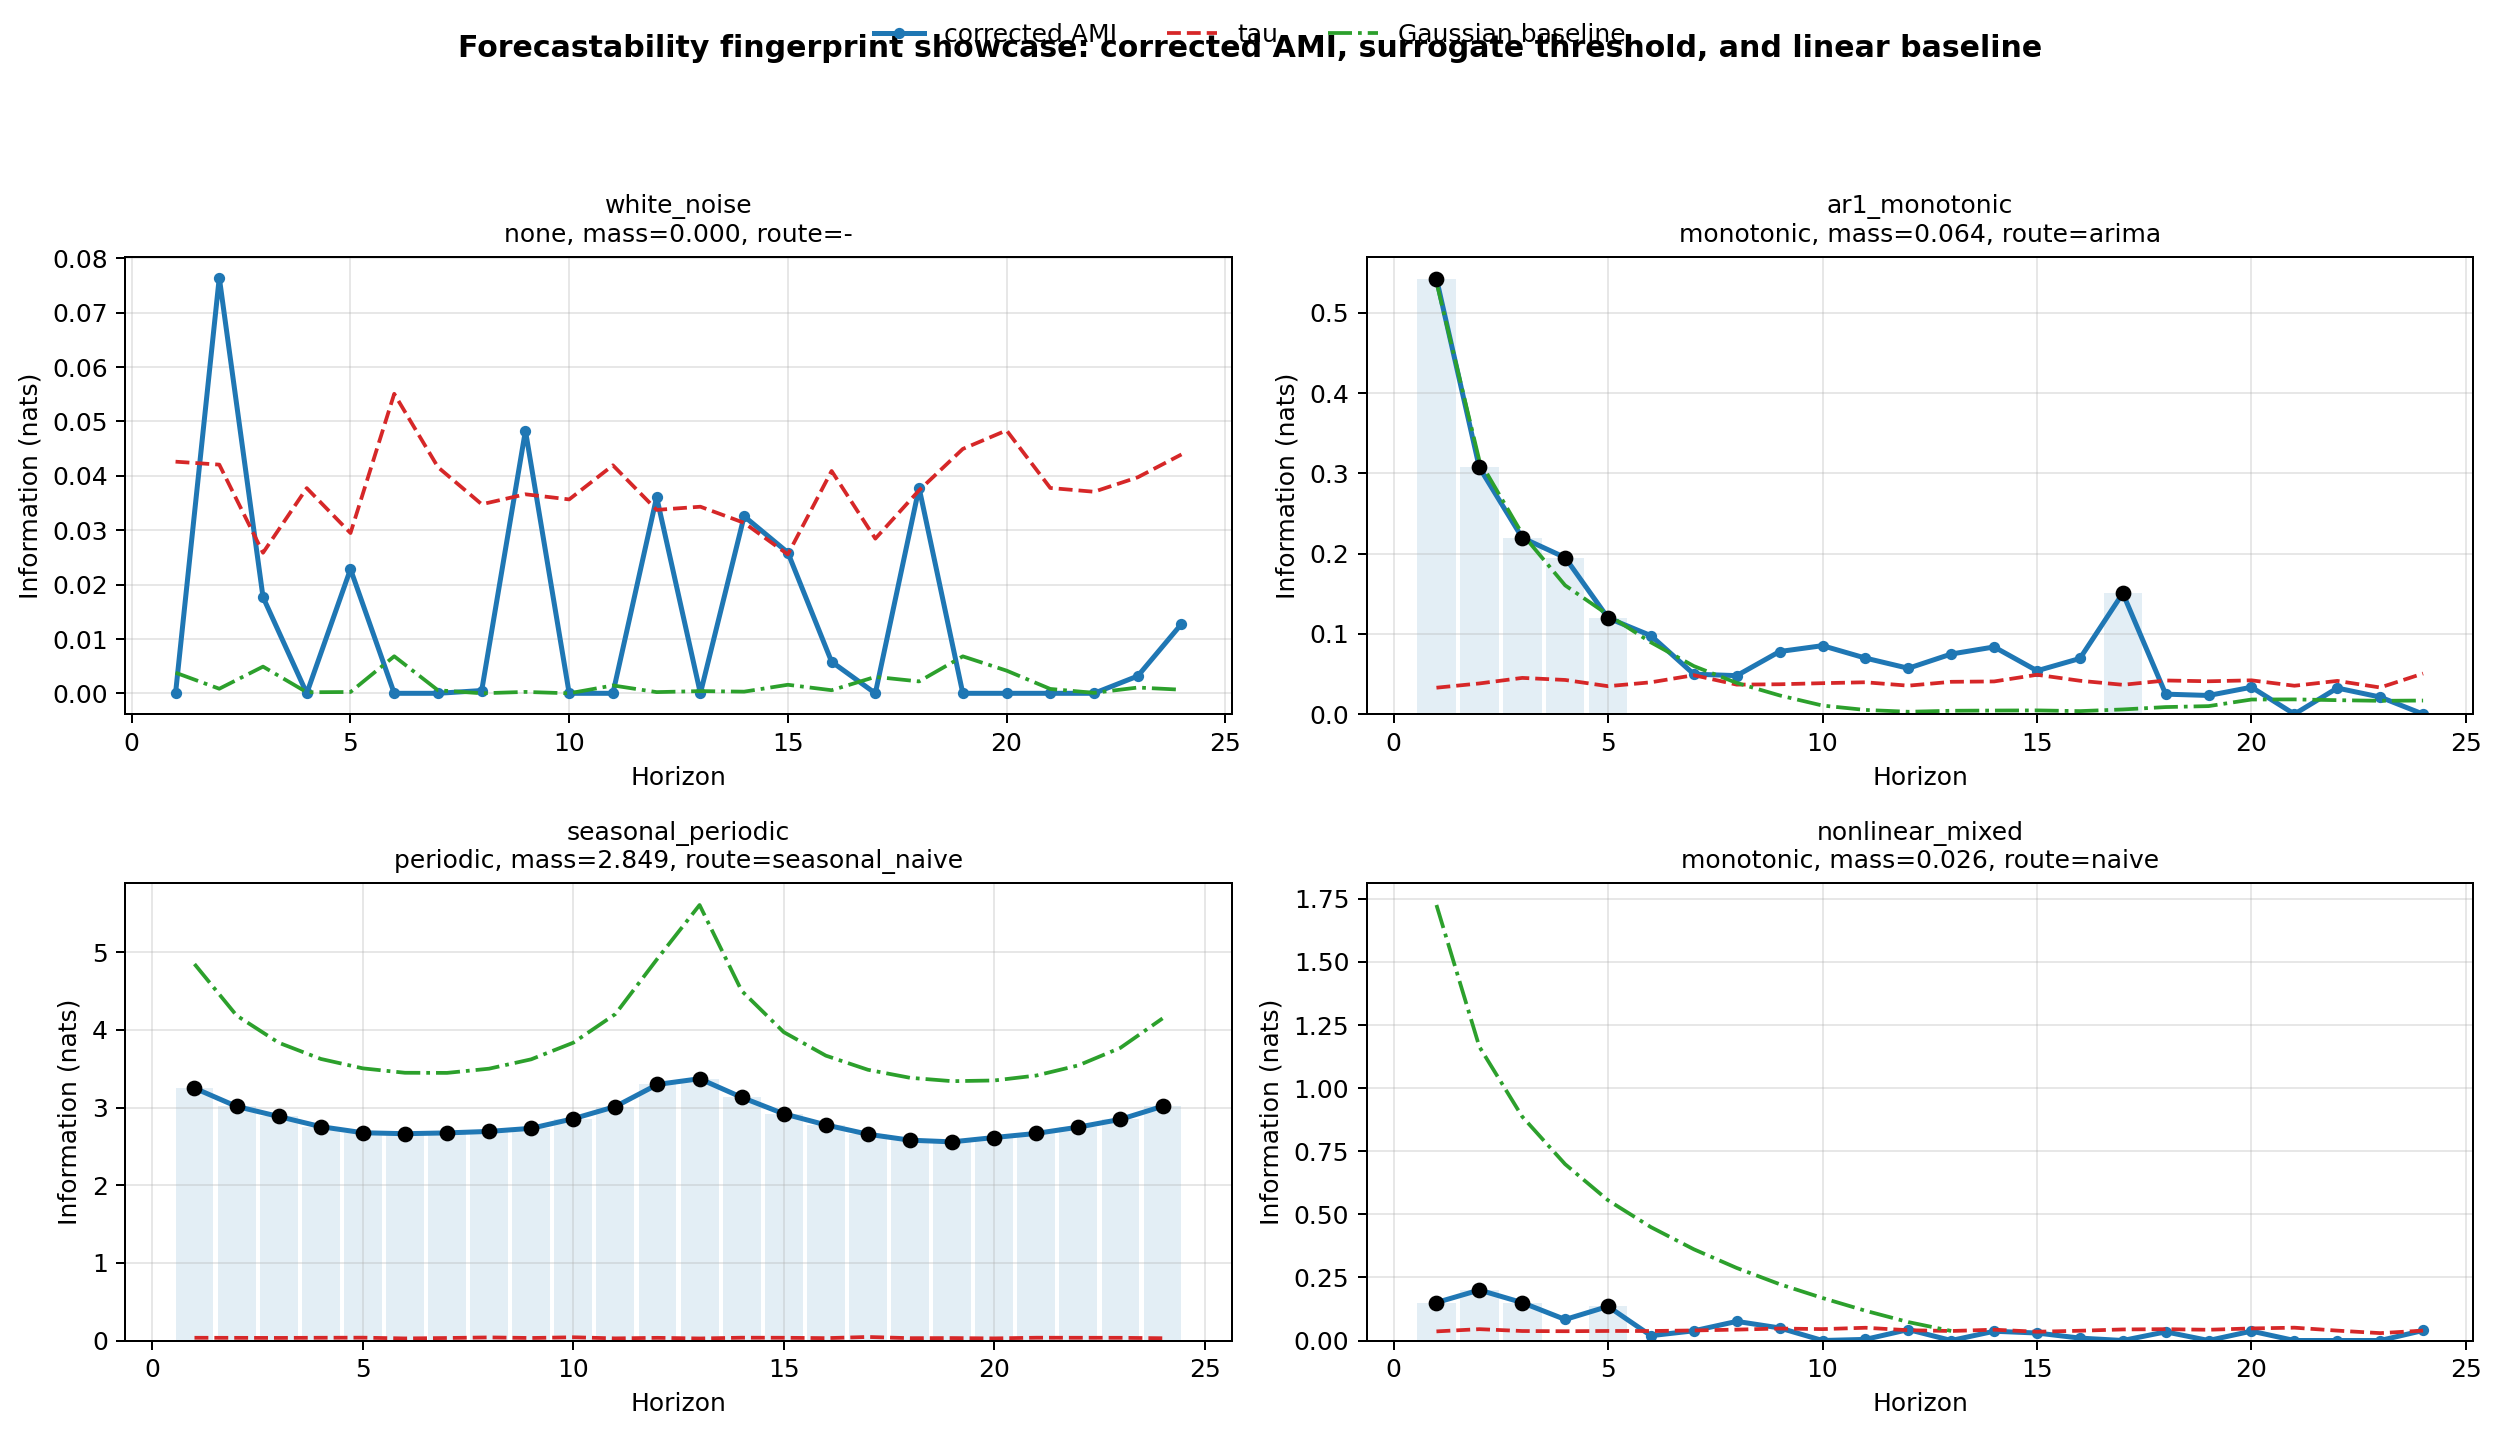

In [6]:
profile_path = FIG_DIR / "fingerprint_profiles.png"
save_showcase_profile_grid(records, output_path=profile_path)
write_frame_csv(fingerprint_profile_frame(records[0]), output_path=TABLE_DIR / "white_noise_profile.csv")
Image(filename=str(profile_path))


## G — nonlinear_share walkthrough against Gaussian baseline

`nonlinear_share` is not the same thing as “complexity.” It asks a narrower question:
how much of the accepted corrected AMI still remains after subtracting the information one
would expect from plain linear autocorrelation? High values push routing toward richer
nonlinear families; low values keep the route in linear or seasonal families.


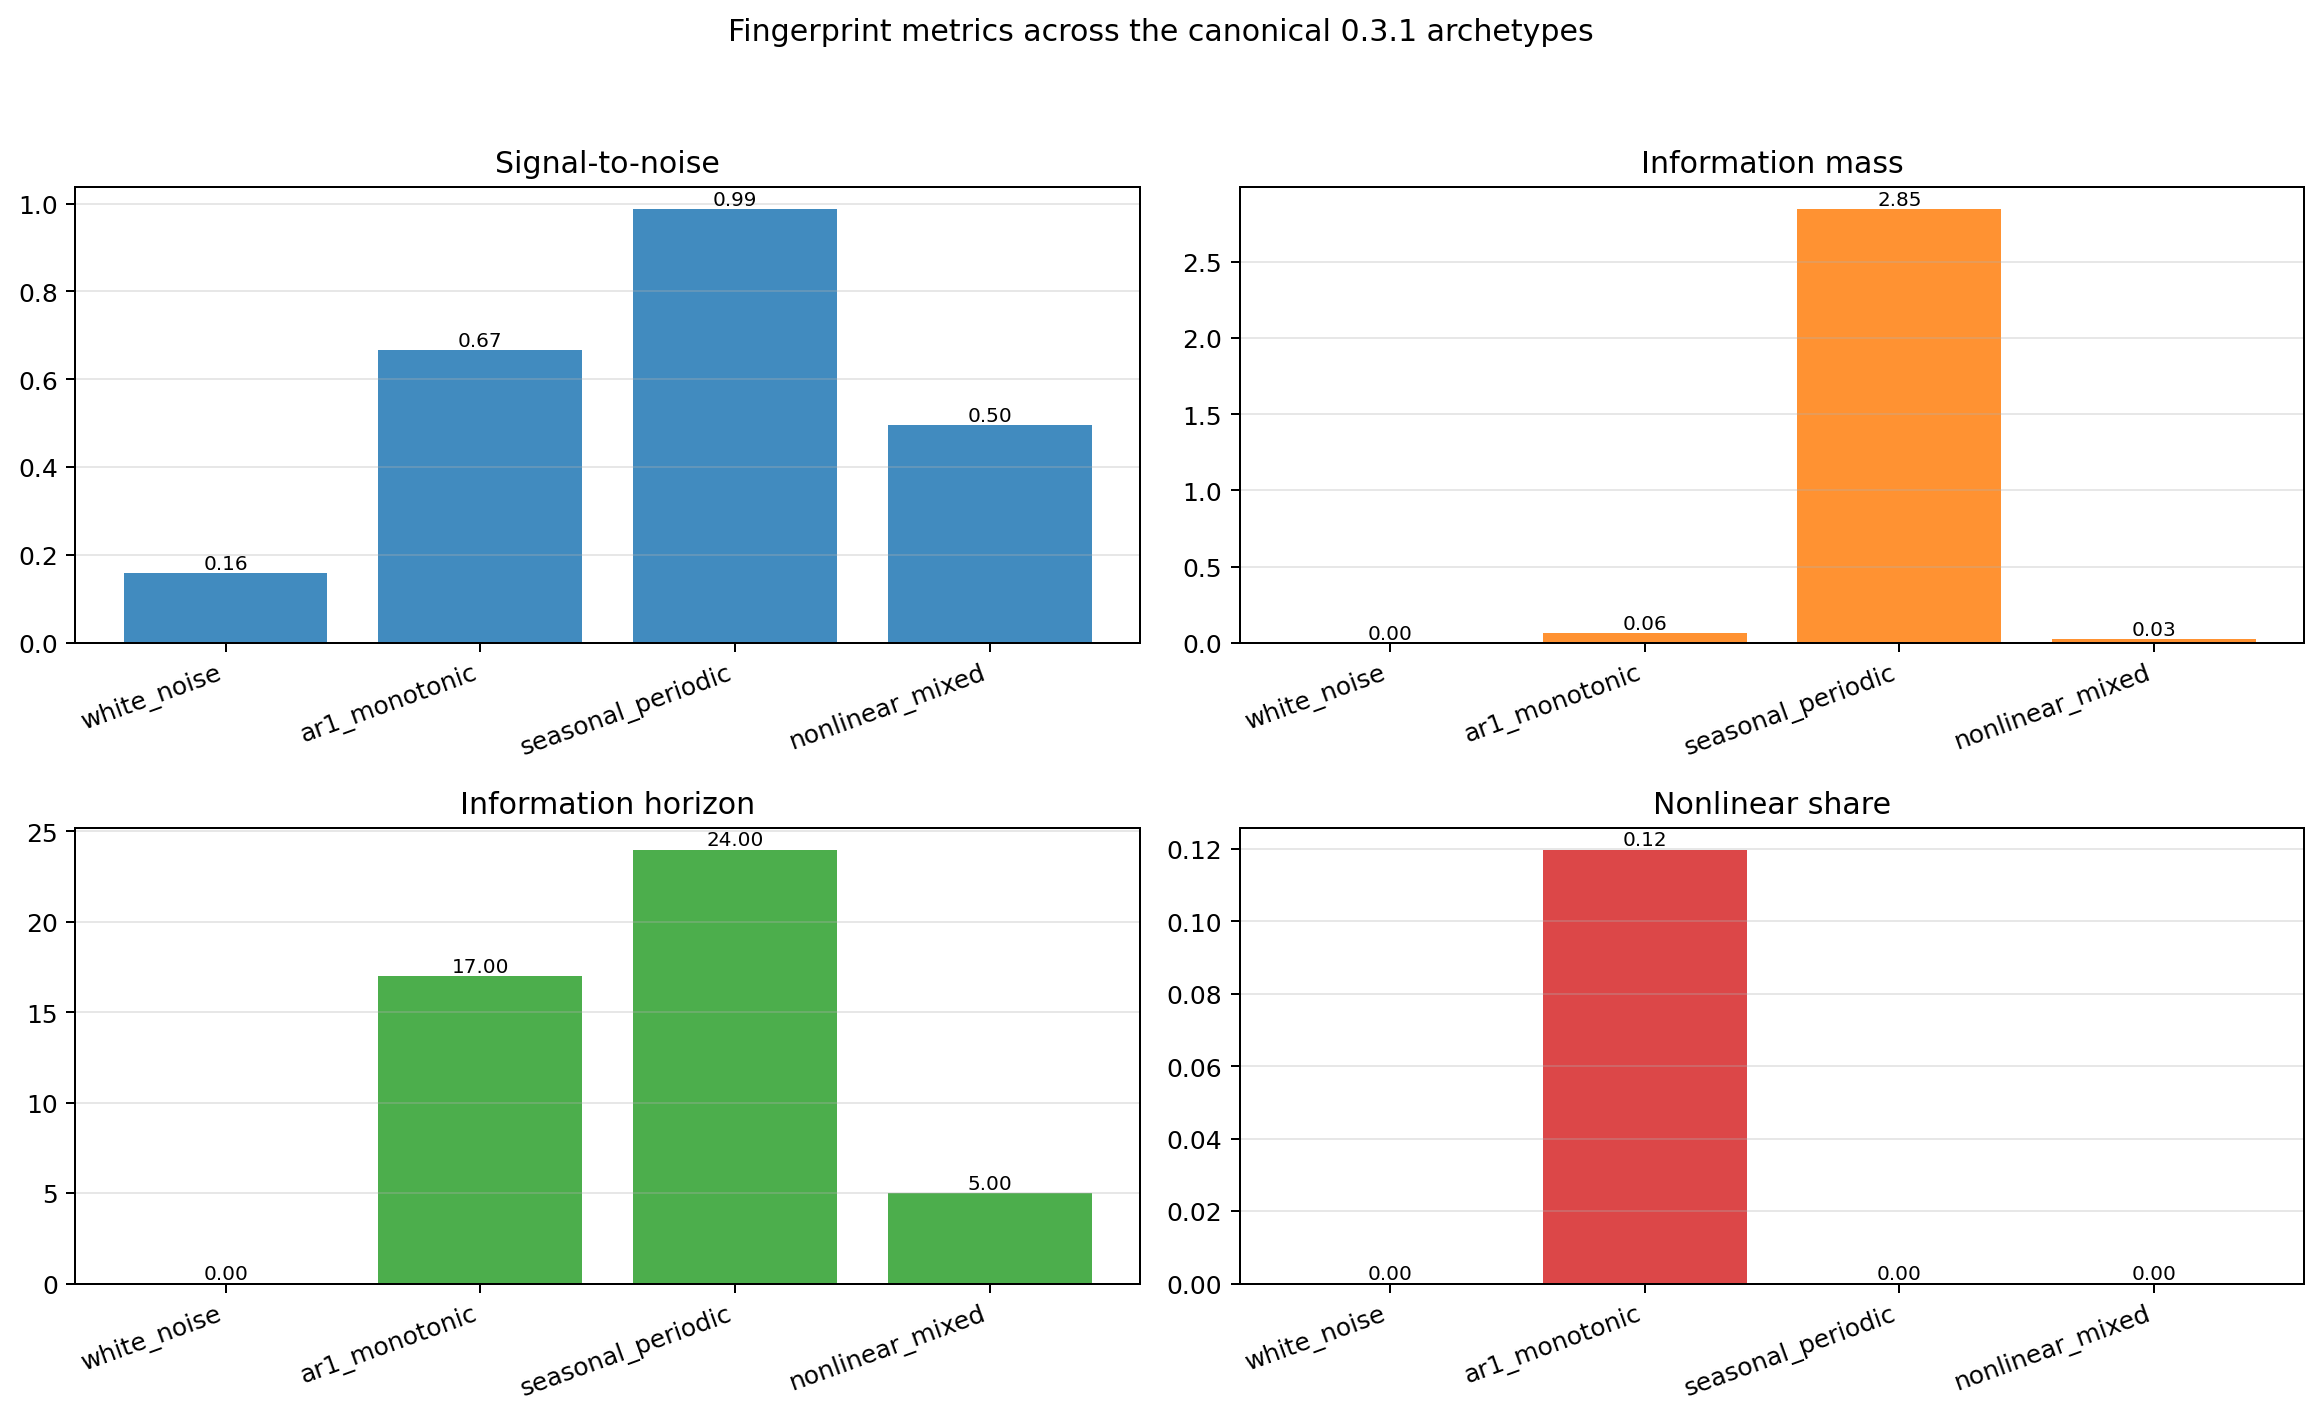

In [7]:
metric_path = FIG_DIR / "fingerprint_metrics.png"
save_metric_overview(records, output_path=metric_path)
Image(filename=str(metric_path))


## H — Routing walkthrough with caution flags and confidence labels

Routing is deterministic family guidance, not exact-model selection. The comparison table
shows which family groups the policy prefers, what caveats it raises, and how the strict
A3 agent summarizes those results without changing them.


In [8]:
write_frame_csv(summary_frame, output_path=TABLE_DIR / "fingerprint_summary.csv")
write_frame_csv(routing_frame, output_path=TABLE_DIR / "fingerprint_routing.csv")
routing_frame[[
    "target_name",
    "primary_families",
    "secondary_families",
    "confidence_label",
    "caution_flags",
]]


,target_name,primary_families,secondary_families,confidence_label,caution_flags
0,white_noise,-,-,abstain,-
1,ar1_monotonic,"arima, ets, linear_state_space",dynamic_regression,medium,-
2,seasonal_periodic,"seasonal_naive, harmonic_regression, tbats",seasonal_state_space,medium,-
3,nonlinear_mixed,"naive, seasonal_naive, downscope",-,medium,near_threshold


## I — Agent-layer summary in plain language

The strict deterministic A3 layer is the showcase’s human-facing compression surface. It
reads the same deterministic payload the script writes to JSON and translates the math into
plain language. This keeps the explanation downstream of the numbers, as documented in
[`docs/reference/agent_layer.md`](../../docs/reference/agent_layer.md).

In [9]:
display(Markdown(build_plain_language_math_summary(records)))


The same deterministic chain is applied to every synthetic series:

1. Estimate horizon-wise AMI and subtract the shuffle-surrogate background so only corrected signal remains.
2. Keep only horizons where corrected AMI rises clearly above the threshold `tau`.
3. Compress the accepted profile into four human-usable fields: how much signal survived (`information_mass`), how far it survived (`information_horizon`), what shape it formed (`information_structure`), and how much exceeded a linear autocorrelation baseline (`nonlinear_share`).
4. Route those fields to model families and pass the result through the strict deterministic A3 agent adapter, which is allowed to explain but not allowed to change the numbers.

Applied to the four canonical archetypes:
- `white_noise`: after surrogate correction no horizon cleared the acceptance threshold, so the math says there is no durable lag structure to exploit and the route falls back to `no primary route`.
- `ar1_monotonic`: the accepted profile decays without strong periodic repetition, so the main questions are how much signal remains (information_mass=0.064) and how far it lasts (information_horizon=17); the route therefore stays with `arima, ets, linear_state_space`.
- `seasonal_periodic`: repeated accepted peaks survive out to horizon 24, which reads like recurring seasonal signal; nonlinear_share=0.000, so the route stays with `seasonal_naive, harmonic_regression, tbats`.
- `nonlinear_mixed`: the accepted profile decays without strong periodic repetition, so the main questions are how much signal remains (information_mass=0.026) and how far it lasts (information_horizon=5); the route therefore stays with `naive, seasonal_naive, downscope`.

This showcase remains univariate-first and AMI-first. It does not claim to identify one true optimal model, and it does not introduce multivariate or conditional-MI routing semantics into the fingerprint surface.

## J — Verification and caveats

Two boundaries matter for v0.3.1:

- the A1/A2/A3 agent surfaces must preserve deterministic geometry, fingerprint, and routing fields,
- the fingerprint showcase remains univariate-first and AMI-first; it is not a multivariate or exact-model-selection claim.

If the list below is empty, the notebook and script are consistent with the deterministic package outputs.


In [10]:
verification_issues


[]